<a href="https://colab.research.google.com/github/Aleenapshaji/project_manager/blob/main/House_pricing_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#House_Pricing.csv

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

##Dataset Overview

###Load the dataset House_Pricing.csv

In [ ]:
df_house = pd.read_csv("/content/drive/MyDrive/AI_ML/data/House_Pricing.csv")
df_house.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


###Display basic information about the dataset using .info() and .describe() to understand the features, data types, and any initial insights into missing values

In [ ]:
# To understand datatypes of each features
df_house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [ ]:
# to understabd the standards such as min, max, mean, std, etc
df_house_pricing.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [ ]:
# To check for null values
df_house.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


##Duplicate Removal

###Rows: Check for duplicate rows in the dataset, if any, and remove them

In [ ]:
duplicate_id = df_house[df_house["ID"].duplicated()]

In [ ]:
duplicate_id

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
94,6021501535,14 December 2017,700000.0,3,1.50,1580.0,5000.0,1.0,No,NaN,...,8,1290.0,290,79,0,98117.0,47.6870,-122.386,1570.0,4500
314,4139480200,14 December 2017,1400000.0,4,3.25,4290.0,12103.0,1.0,No,Thrice,...,10,2690.0,1600,21,0,98006.0,47.5503,-122.102,3860.0,11244
325,7520000520,15 March 2016,240500.0,2,1.00,1240.0,12092.0,1.0,No,NaN,...,6,960.0,280,96,1984,98146.0,47.4957,-122.352,1820.0,7460
346,3969300030,14 December 2017,239900.0,4,1.00,1000.0,7134.0,1.0,No,NaN,...,6,1000.0,0,75,0,98178.0,47.4897,-122.240,1020.0,7138
372,2231500030,15 March 2016,530000.0,4,2.25,NaN,10754.0,1.0,No,NaN,...,7,1100.0,1080,64,0,98133.0,47.7711,-122.341,1810.0,6929
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20181,7853400250,15 February 2016,645000.0,4,3.50,2910.0,5260.0,2.0,No,NaN,...,9,2910.0,0,6,0,98065.0,47.5168,-121.883,2910.0,5260
20613,2724049222,14 December 2017,220000.0,2,2.50,1000.0,1092.0,2.0,No,NaN,...,7,990.0,10,14,0,98118.0,47.5419,-122.271,1330.0,1466
20670,8564860270,15 March 2016,502000.0,4,2.50,2680.0,5539.0,2.0,No,NaN,...,8,2680.0,0,5,0,98045.0,47.4759,-121.734,2680.0,5992
20780,6300000226,15 May 2016,380000.0,4,1.00,1200.0,2171.0,1.5,No,NaN,...,7,1200.0,0,85,0,98133.0,47.7076,-122.342,1130.0,1598


In [ ]:
duplicate_id = df_house[df_house["ID"].duplicated(keep=False)]

print(f"Rows sharing duplicate IDs : {duplicate_id.shape[0]}")
duplicate_id.head()

Rows sharing duplicate IDs : 353


,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
93,6021501535,14 July 2017,430000.0,3,1.50,1580.0,5000.0,1.0,No,NaN,...,8,1290.0,290,79,0,98117.0,47.6870,-122.386,1570.0,4500
94,6021501535,14 December 2017,700000.0,3,1.50,1580.0,5000.0,1.0,No,NaN,...,8,1290.0,290,79,0,98117.0,47.6870,-122.386,1570.0,4500
313,4139480200,14 June 2017,1380000.0,4,3.25,4290.0,12103.0,1.0,No,Thrice,...,10,2690.0,1600,21,0,98006.0,47.5503,-122.102,3860.0,11244
314,4139480200,14 December 2017,1400000.0,4,3.25,4290.0,12103.0,1.0,No,Thrice,...,10,2690.0,1600,21,0,98006.0,47.5503,-122.102,3860.0,11244
324,7520000520,14 September 2017,232000.0,2,1.00,1240.0,12092.0,1.0,No,NaN,...,6,960.0,280,96,1984,98146.0,47.4957,-122.352,1820.0,7460


In [ ]:
# Check complete duplicate rows
df_house.duplicated().sum()

np.int64(0)

###Columns: Identify and drop duplicate columns, if any, based on their values.

In [ ]:
# Dropping the missing value column.
df_house = df_house.drop_duplicates()

In [ ]:
# Checking for duplicate columns
duplicate_cols = []

for i in range(len(df_house.columns)):
  for j in range(i + 1, len(df_house.columns)):
    if df_house.iloc[:, i].equals(df_house.iloc[:, j]):
      duplicate_cols.append(df_house.columns[j])

print("Duplicate Columns:", duplicate_cols)

Duplicate Columns: []


In [ ]:
# Removing duplicate columns if present
df_house.drop(columns=duplicate_cols, inplace=True)

In [ ]:
df_house.shape

(21613, 21)

In [ ]:
df_house

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,14 May 2017,360000.0,3,2.50,1530.0,1131.0,3.0,No,NaN,...,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,15 February 2016,400000.0,4,2.50,2310.0,5813.0,2.0,No,NaN,...,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,14 June 2017,402101.0,2,0.75,1020.0,1350.0,2.0,No,NaN,...,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,15 January 2016,400000.0,3,2.50,1600.0,2388.0,2.0,No,NaN,...,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287


In [ ]:
df_house.drop(columns="ID", inplace=True)

##Handling Missing Values

###Identify missing values in each column

In [ ]:
#Finding the number of missinsg values
df_house.isna().sum()

,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489
Condition of the House,0


In [ ]:
# TARGET COLUMN : Sale Price
df_house.dropna(subset=["Sale Price"], inplace=True)  # Removing rows where target is missing

###Handle missing values:
*For numerical columns, use imputation techniques like mean/median imputation.

*For categorical columns, fill with mode.

In [ ]:
num_cols = df_house.select_dtypes(include=np.number).columns
cat_cols = df_house.select_dtypes(include="object").columns
df_house.head()

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [ ]:
# median() is used because it is less sensitive to outliers, compared to mean
df_house[num_cols] = df_house[num_cols].fillna(df_house[num_cols].median())
df_house.head()

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [ ]:
# mode() is used due to "dealing with categorical data"
df_house[cat_cols] = df_house[cat_cols].fillna(df_house[cat_cols].mode().iloc[0])
df_house.head()

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,Twice,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,Twice,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,Twice,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,Twice,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,Twice,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [ ]:
# Converting strings -> datetime
df_house["Date House was Sold"] = pd.to_datetime(df_house["Date House was Sold"])
# Now we can access individual components using .dt
df_house.head()

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,2017-10-14,221900.0,3,1.00,1180.0,5650.0,1.0,No,Twice,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,2017-12-14,538000.0,3,2.25,2570.0,7242.0,2.0,No,Twice,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,2016-02-15,180000.0,2,1.00,770.0,10000.0,1.0,No,Twice,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2017-12-14,604000.0,4,3.00,1960.0,5000.0,1.0,No,Twice,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,2016-02-15,510000.0,3,2.00,1680.0,8080.0,1.0,No,Twice,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [ ]:
df_house.columns

Index(['Date House was Sold', 'Sale Price', 'No of Bedrooms',
       'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)',
       'No of Floors', 'Waterfront View', 'No of Times Visited',
       'Condition of the House', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [ ]:
# Extracting and Creating new features:
# yead and month are extracted because house prices can vary over time

df_house.head()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,...,Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Year_Sold,Month_Sold
0,221900.0,3,1.00,1180.0,5650.0,1.0,No,Twice,Fair,7,...,0,63,0,98178.0,47.5112,-122.257,1340.0,5650,2017,10
1,538000.0,3,2.25,2570.0,7242.0,2.0,No,Twice,Fair,7,...,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639,2017,12
2,180000.0,2,1.00,770.0,10000.0,1.0,No,Twice,Fair,6,...,0,85,0,98028.0,47.7379,-122.233,2720.0,8062,2016,2
3,604000.0,4,3.00,1960.0,5000.0,1.0,No,Twice,Excellent,7,...,910,53,0,98136.0,47.5208,-122.393,1360.0,5000,2017,12
4,510000.0,3,2.00,1680.0,8080.0,1.0,No,Twice,Fair,8,...,0,31,0,98074.0,47.6168,-122.045,1800.0,7503,2016,2


##Encoding Categorical Variables

###Identify all categorical columns in the dataset.
Apply appropriate encoding techniques:

*Use One-Hot Encoding for nominal categories.

*Use Label Encoding for ordinal categories, if applicable

### One-Hot Encoding

In [ ]:
cat_cols = df_house.select_dtypes(include='object').columns.tolist()

In [ ]:
binary_cols = []

for col in cat_cols:
  if df_house[col].nunique() == 2:
    binary_cols.append(col)
df_house.head()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,...,Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Year_Sold,Month_Sold
0,221900.0,3,1.00,1180.0,5650.0,1.0,No,Twice,Fair,7,...,0,63,0,98178.0,47.5112,-122.257,1340.0,5650,2017,10
1,538000.0,3,2.25,2570.0,7242.0,2.0,No,Twice,Fair,7,...,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639,2017,12
2,180000.0,2,1.00,770.0,10000.0,1.0,No,Twice,Fair,6,...,0,85,0,98028.0,47.7379,-122.233,2720.0,8062,2016,2
3,604000.0,4,3.00,1960.0,5000.0,1.0,No,Twice,Excellent,7,...,910,53,0,98136.0,47.5208,-122.393,1360.0,5000,2017,12
4,510000.0,3,2.00,1680.0,8080.0,1.0,No,Twice,Fair,8,...,0,31,0,98074.0,47.6168,-122.045,1800.0,7503,2016,2


In [ ]:
binary_cols

['Waterfront View']

In [ ]:
binary_cols = ['Correct_Column_Name']


In [ ]:
remaining_cat = df_house.select_dtypes(include="object").columns
df_house.head()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Year_Sold,Month_Sold,Waterfront View_Yes
0,221900.0,3,1.00,1180.0,5650.0,1.0,Twice,Fair,7,1180.0,...,63,0,98178.0,47.5112,-122.257,1340.0,5650,2017,10,False
1,538000.0,3,2.25,2570.0,7242.0,2.0,Twice,Fair,7,2170.0,...,67,1991,98125.0,47.7210,-122.319,1690.0,7639,2017,12,False
2,180000.0,2,1.00,770.0,10000.0,1.0,Twice,Fair,6,770.0,...,85,0,98028.0,47.7379,-122.233,2720.0,8062,2016,2,False
3,604000.0,4,3.00,1960.0,5000.0,1.0,Twice,Excellent,7,1050.0,...,53,0,98136.0,47.5208,-122.393,1360.0,5000,2017,12,False
4,510000.0,3,2.00,1680.0,8080.0,1.0,Twice,Fair,8,1680.0,...,31,0,98074.0,47.6168,-122.045,1800.0,7503,2016,2,False


In [ ]:
df_house = pd.get_dummies(df_house,columns=remaining_cat,drop_first=True)
df_house.head()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),...,Year_Sold,Month_Sold,Waterfront View_Yes,No of Times Visited_Once,No of Times Visited_Thrice,No of Times Visited_Twice,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
0,221900.0,3,1.00,1180.0,5650.0,1.0,7,1180.0,0,63,...,2017,10,False,False,False,True,False,True,False,False
1,538000.0,3,2.25,2570.0,7242.0,2.0,7,2170.0,400,67,...,2017,12,False,False,False,True,False,True,False,False
2,180000.0,2,1.00,770.0,10000.0,1.0,6,770.0,0,85,...,2016,2,False,False,False,True,False,True,False,False
3,604000.0,4,3.00,1960.0,5000.0,1.0,7,1050.0,910,53,...,2017,12,False,False,False,True,True,False,False,False
4,510000.0,3,2.00,1680.0,8080.0,1.0,8,1680.0,0,31,...,2016,2,False,False,False,True,False,True,False,False


##Outlier Removal


###Perform an outlier detection analysis on numerical variables (e.g., using the IQR method).

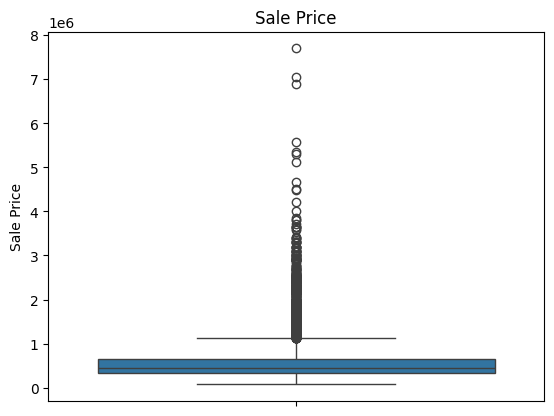

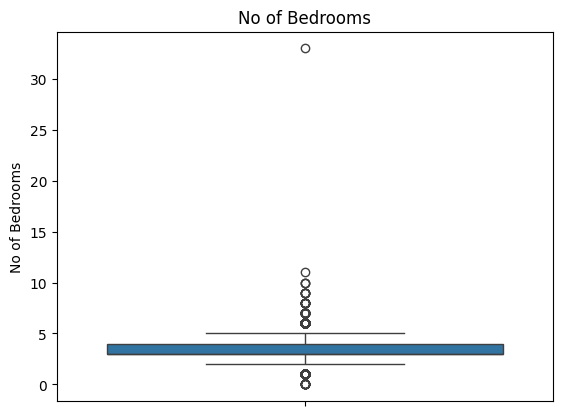

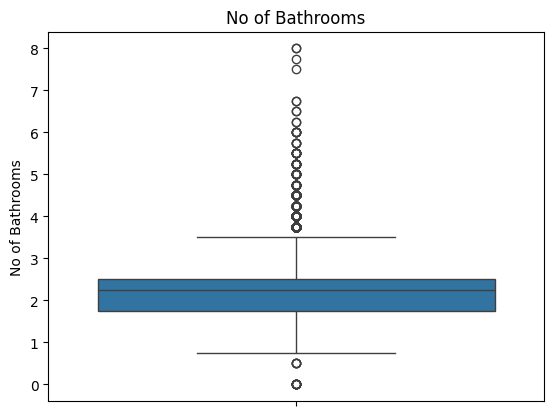

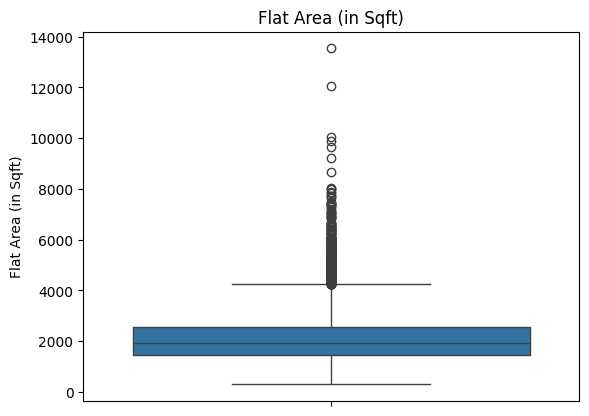

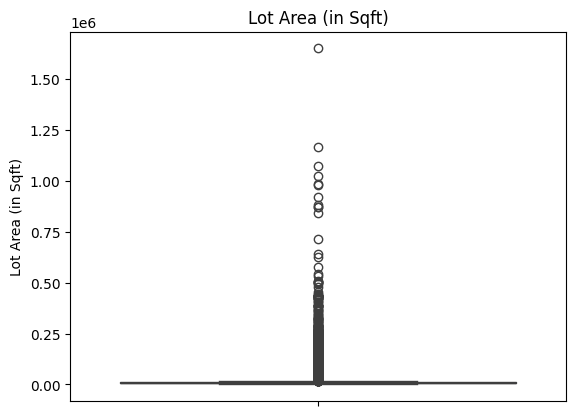

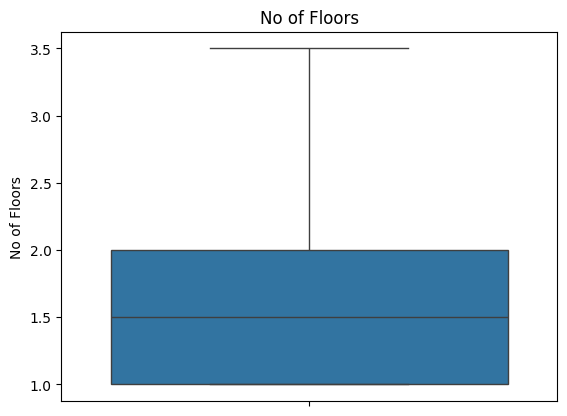

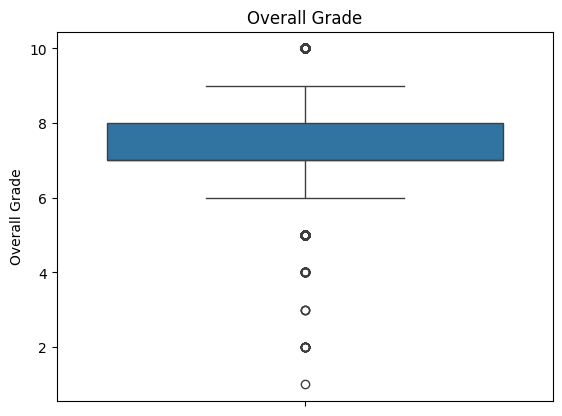

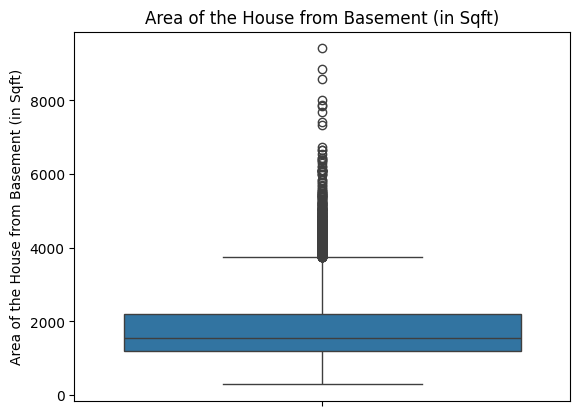

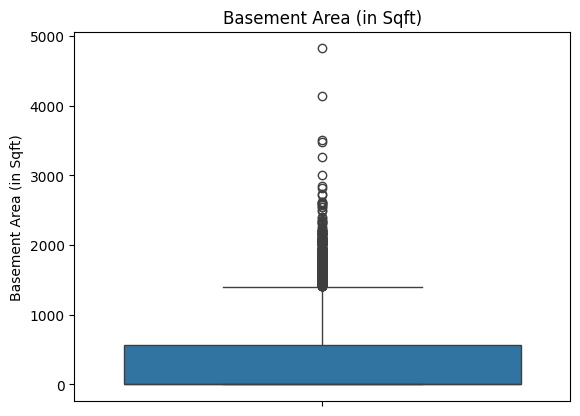

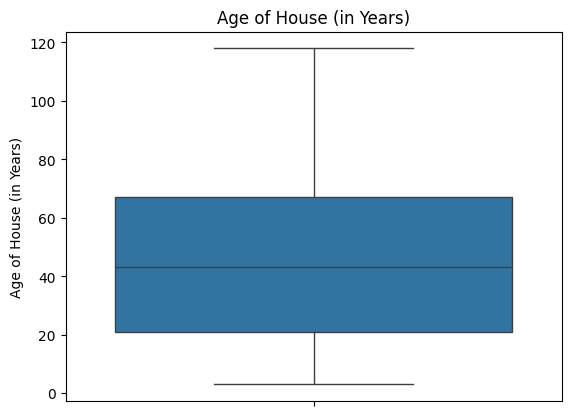

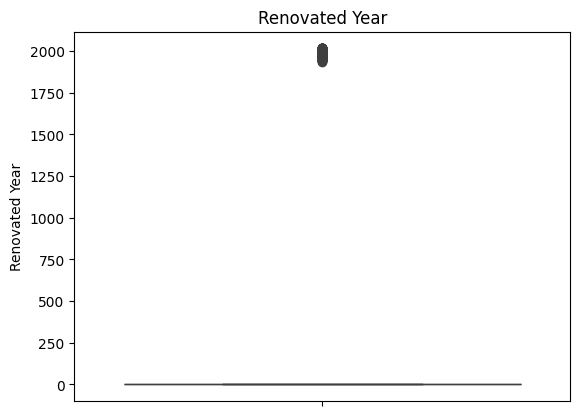

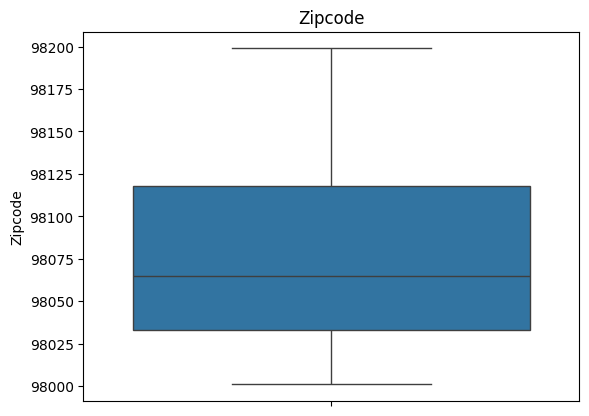

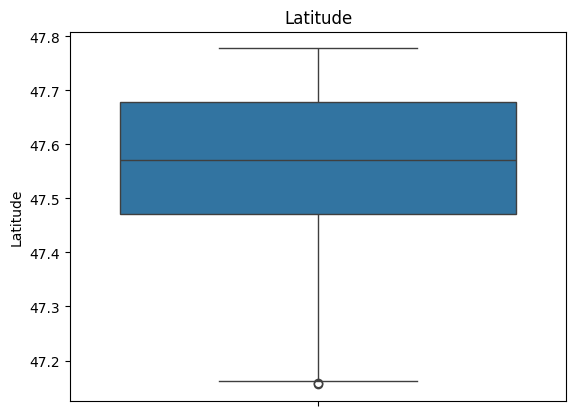

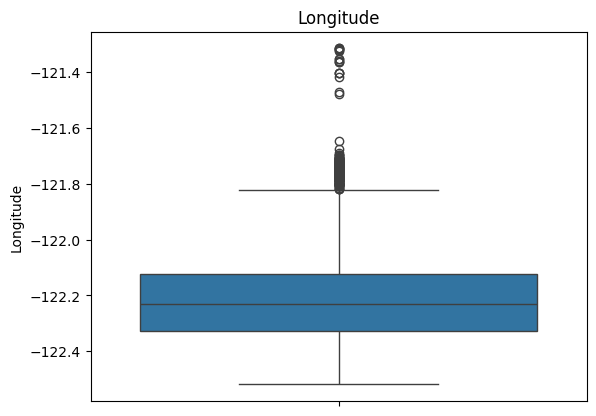

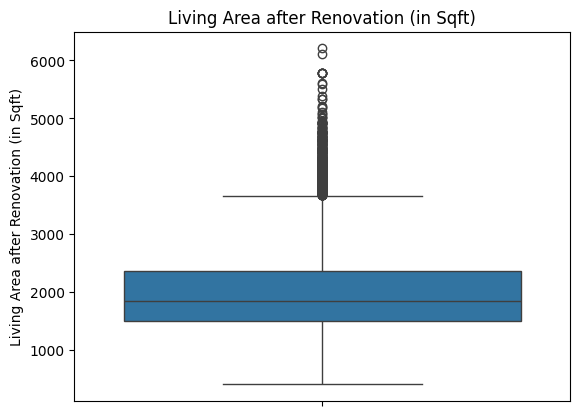

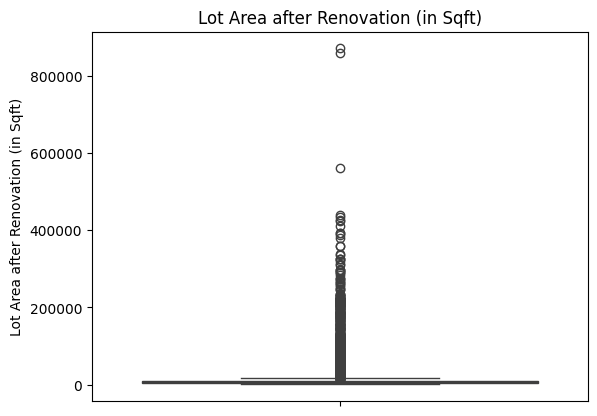

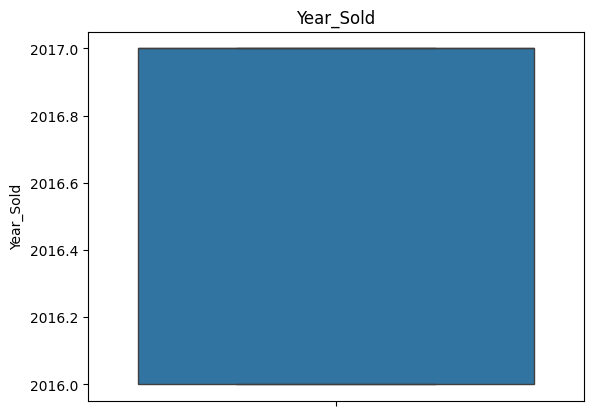

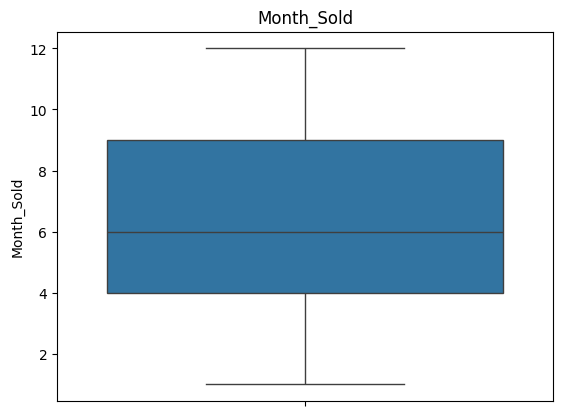

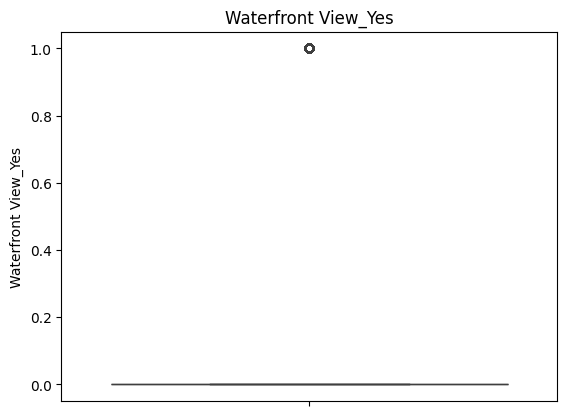

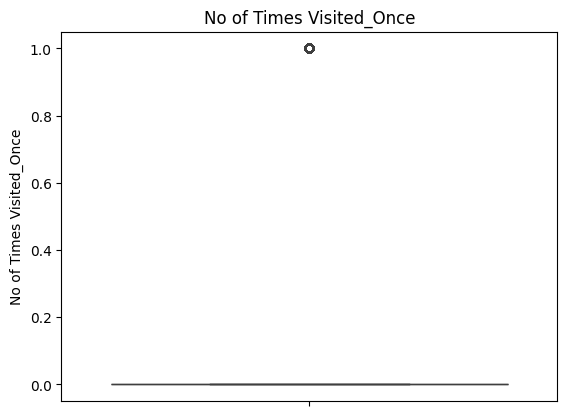

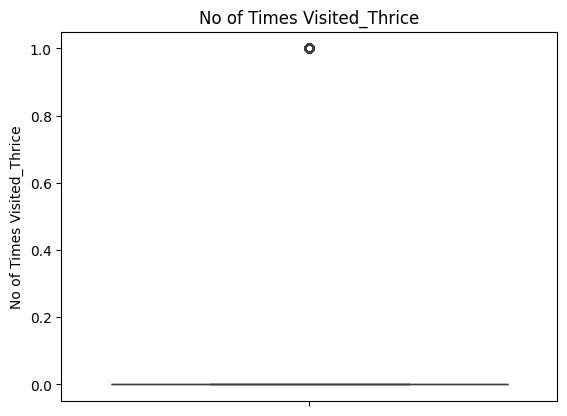

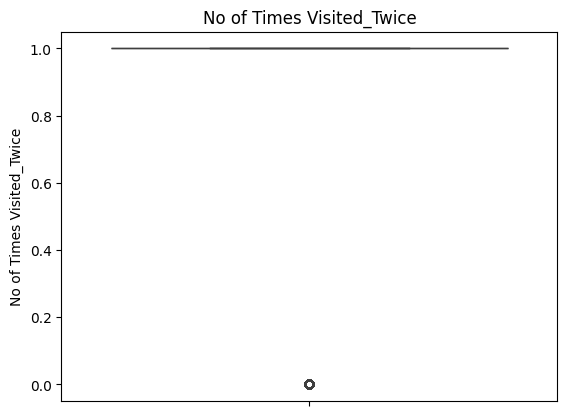

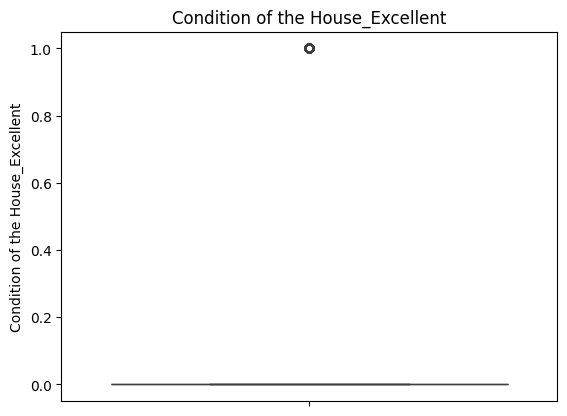

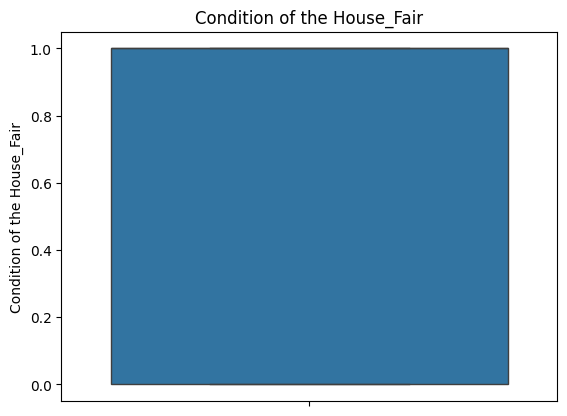

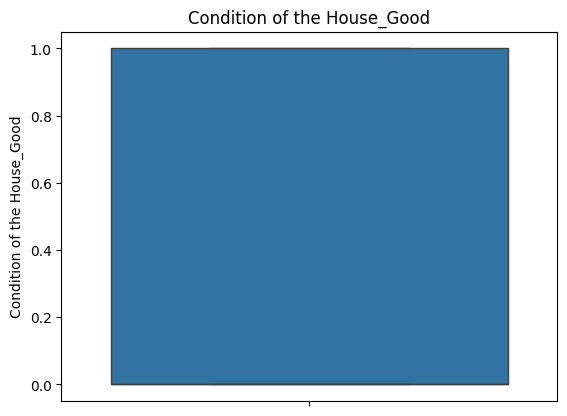

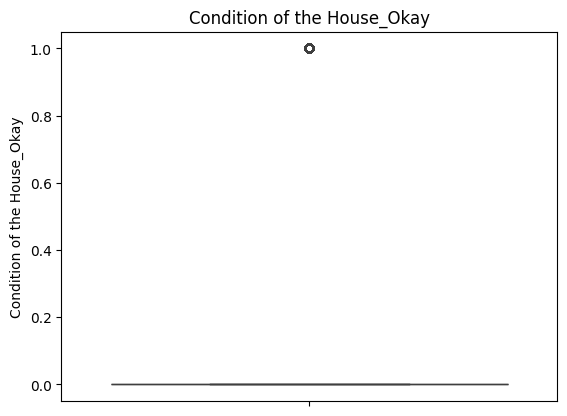

In [ ]:
for columns in df_house:
  sns.boxplot(df_house[columns])
  plt.title(columns)
  plt.show()

###Clipping the Outliers To the UpperBound Or Lowerbound

In [ ]:
for column in df_house.select_dtypes(include="number").columns:  # loop for columns
    Q1 = df_house[column].quantile(0.25)
    Q3 = df_house[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    has_outliers = ((df_house[column] < lower_bound) | (df_house[column] > upper_bound)).any()  # checking for outliers

    if has_outliers:
        df_house[column] = df_house[column].clip(lower=lower_bound, upper=upper_bound)

###After Clipping

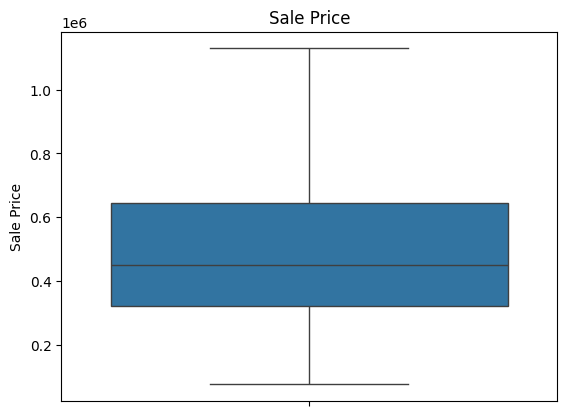

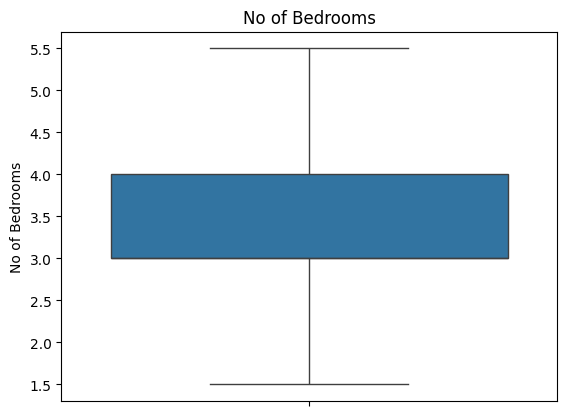

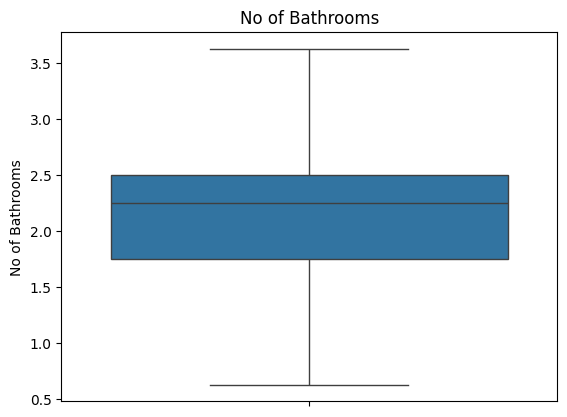

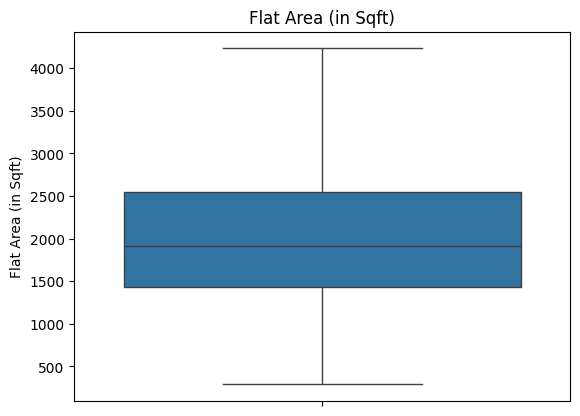

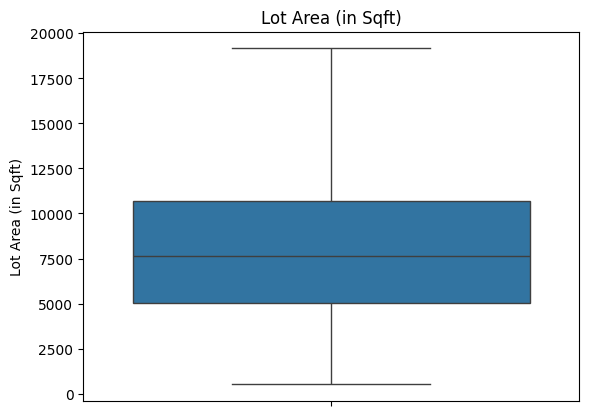

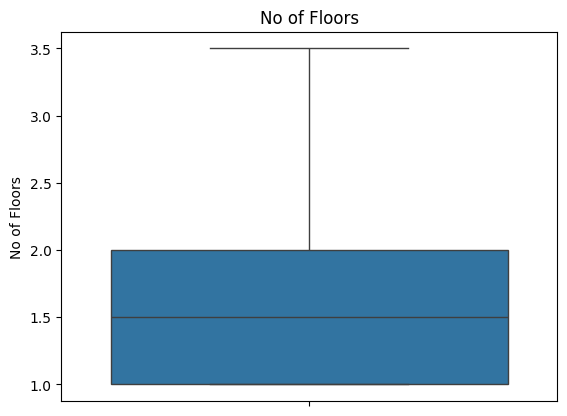

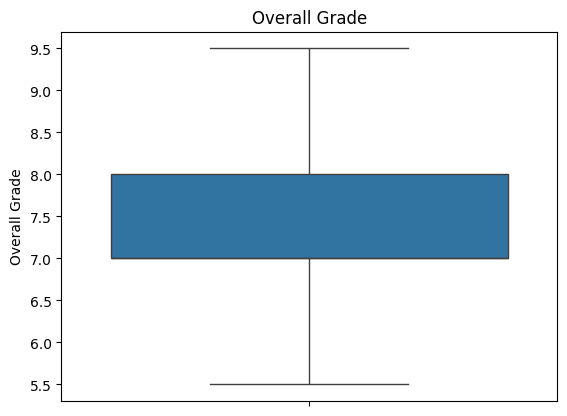

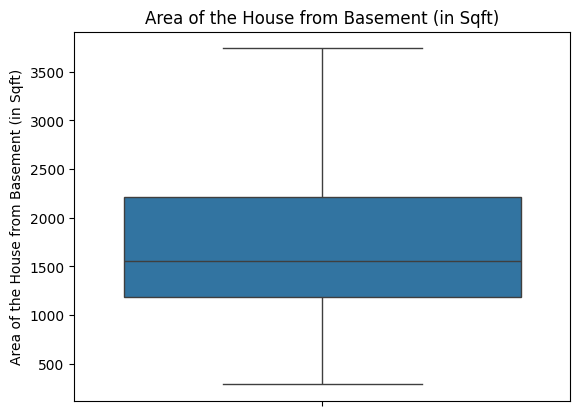

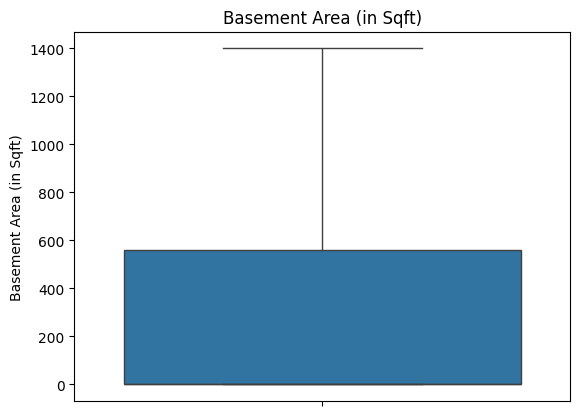

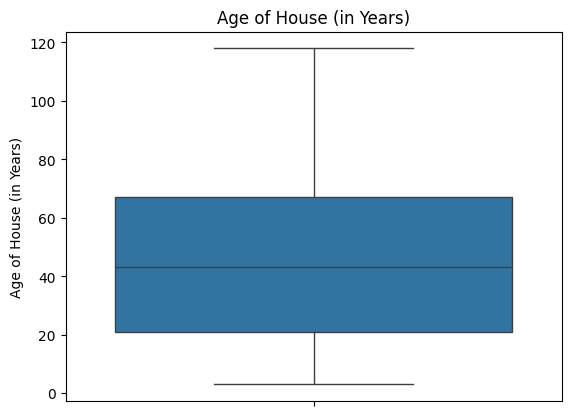

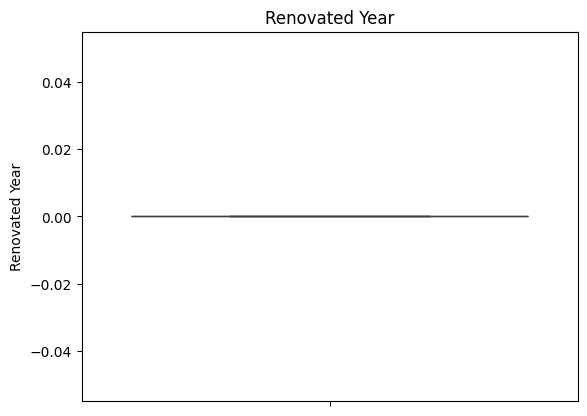

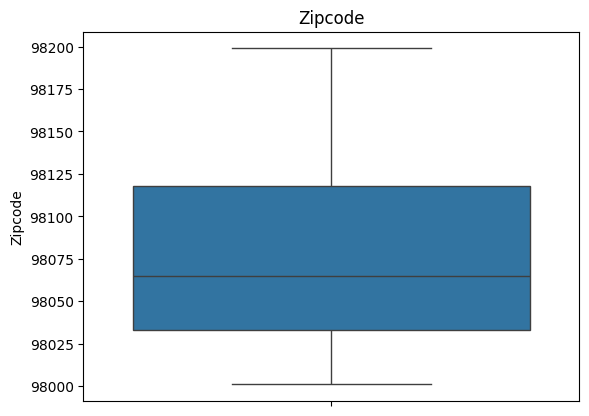

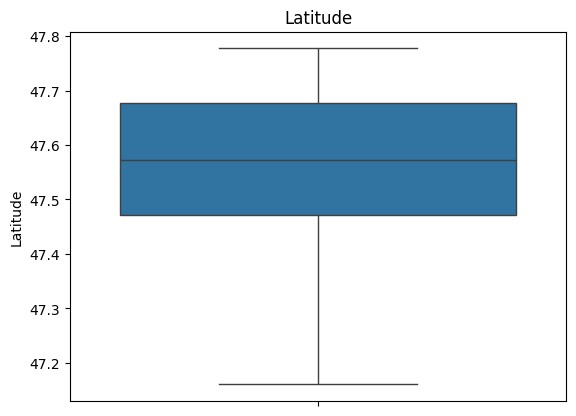

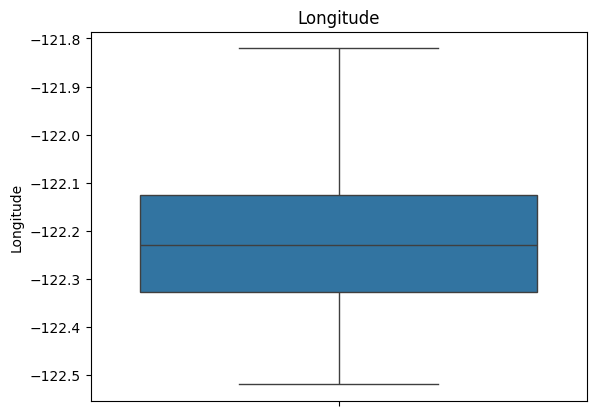

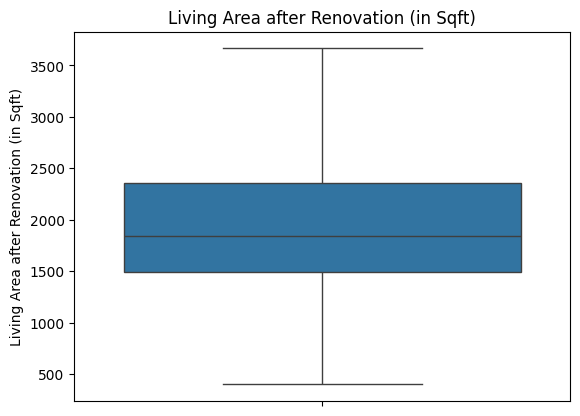

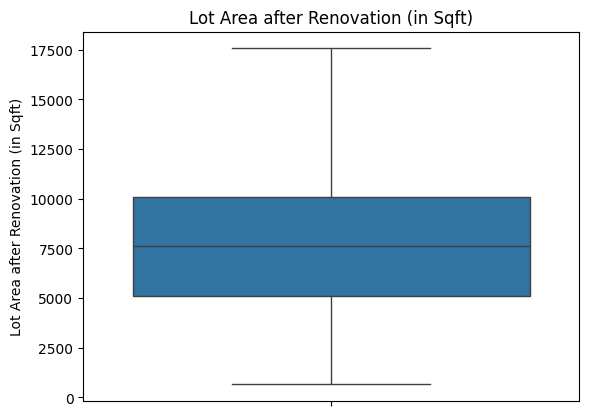

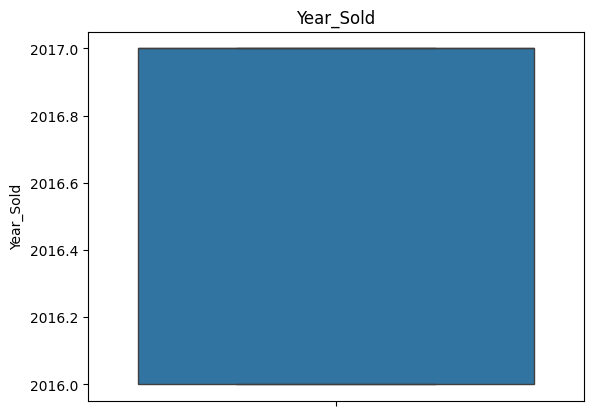

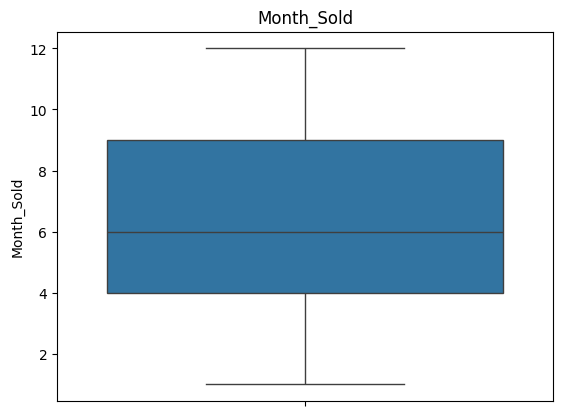

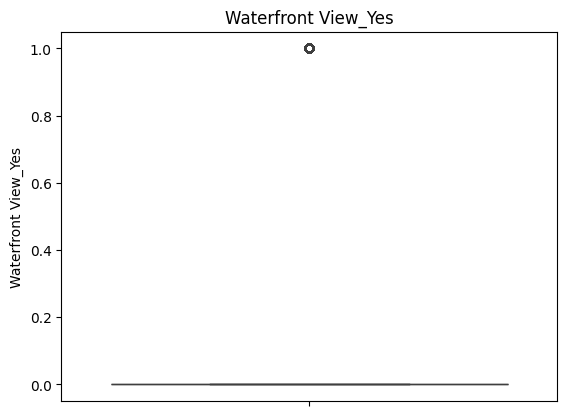

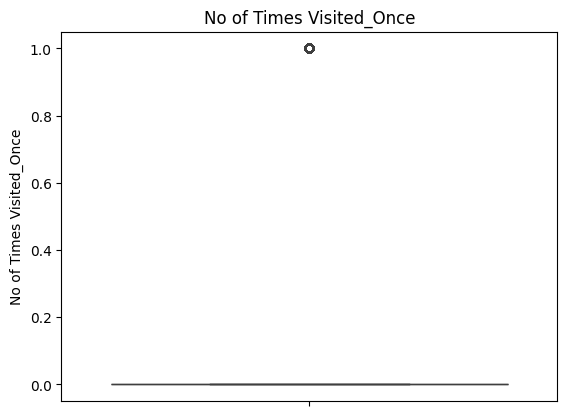

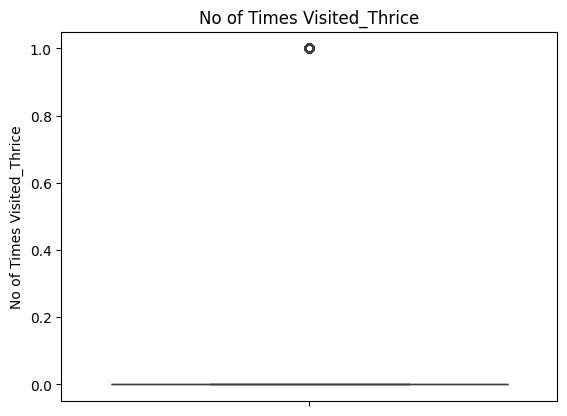

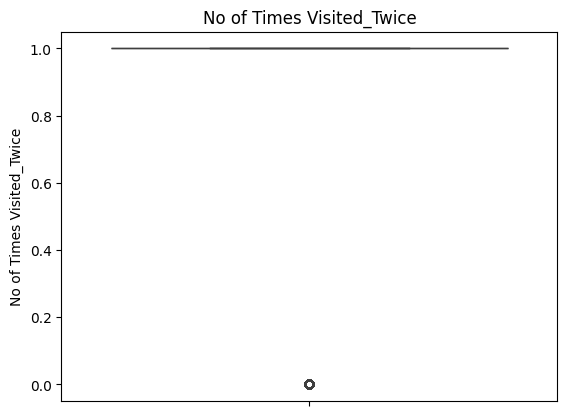

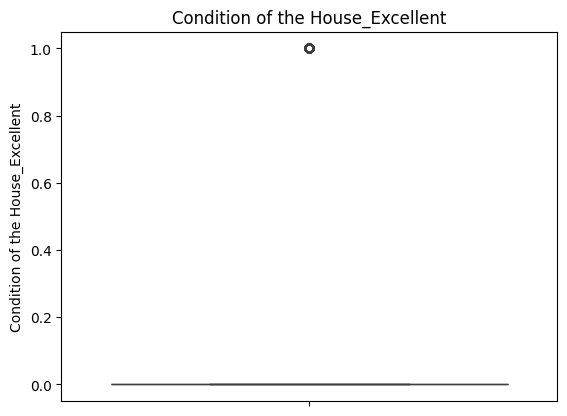

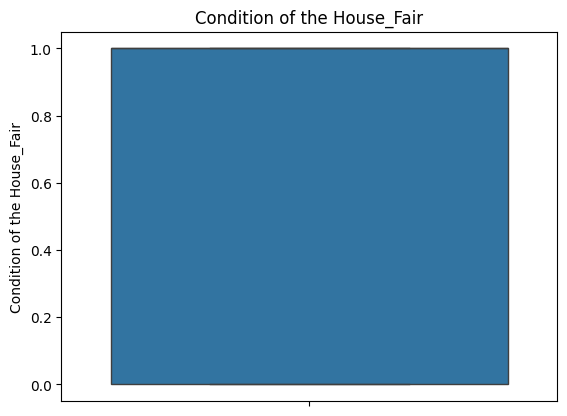

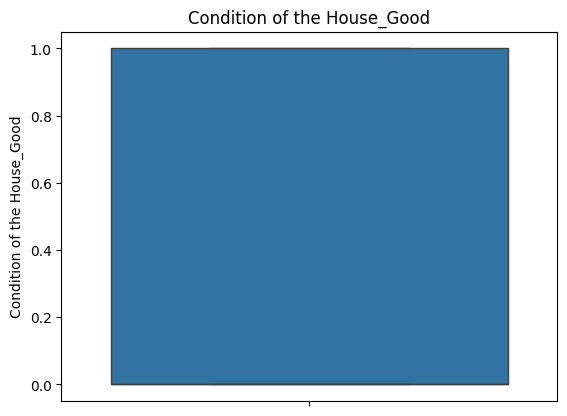

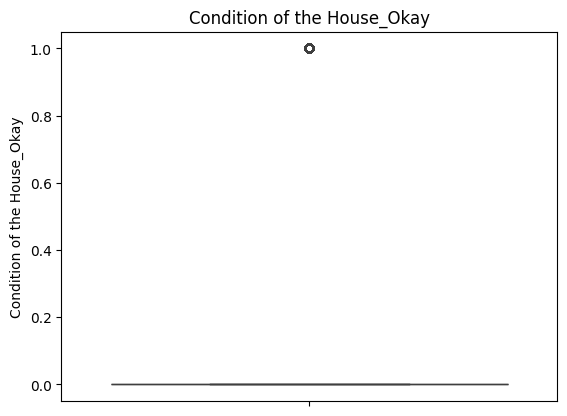

In [ ]:
for columns in df_house:
    sns.boxplot(df_house[columns])
    plt.title(columns)
    plt.show()

In [ ]:
# Features
X = df_house.drop(columns=['Sale Price'])

# Target
y = df_house['Sale Price']

In [ ]:
for col in df_house.columns:
    print(col)

Sale Price
No of Bedrooms
No of Bathrooms
Flat Area (in Sqft)
Lot Area (in Sqft)
No of Floors
Overall Grade
Area of the House from Basement (in Sqft)
Basement Area (in Sqft)
Age of House (in Years)
Renovated Year
Zipcode
Latitude
Longitude
Living Area after Renovation (in Sqft)
Lot Area after Renovation (in Sqft)
Year_Sold
Month_Sold
Waterfront View_Yes
No of Times Visited_Once
No of Times Visited_Thrice
No of Times Visited_Twice
Condition of the House_Excellent
Condition of the House_Fair
Condition of the House_Good
Condition of the House_Okay


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
df_house.head()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),...,Year_Sold,Month_Sold,Waterfront View_Yes,No of Times Visited_Once,No of Times Visited_Thrice,No of Times Visited_Twice,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
0,221900.0,3.0,1.00,1180.0,5650.0,1.0,7.0,1180.0,0,63,...,2017,10,False,False,False,True,False,True,False,False
1,538000.0,3.0,2.25,2570.0,7242.0,2.0,7.0,2170.0,400,67,...,2017,12,False,False,False,True,False,True,False,False
2,180000.0,2.0,1.00,770.0,10000.0,1.0,6.0,770.0,0,85,...,2016,2,False,False,False,True,False,True,False,False
3,604000.0,4.0,3.00,1960.0,5000.0,1.0,7.0,1050.0,910,53,...,2017,12,False,False,False,True,True,False,False,False
4,510000.0,3.0,2.00,1680.0,8080.0,1.0,8.0,1680.0,0,31,...,2016,2,False,False,False,True,False,True,False,False


In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (17287, 25)
X_test shape: (4322, 25)
y_train shape: (17287,)
y_test shape: (4322,)
